<a href="https://colab.research.google.com/github/Bukunmi2108/ml-journey/blob/main/research/p1/mamba/mamba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementation of the Mamba Architecture

In [23]:
import tiktoken
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
import urllib.request as req
import math

In [24]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

In [25]:
try:
    with req.urlopen(url) as response:
        raw_text = response.read().decode('utf-8')
    print("Total Length", len(raw_text))
except:
    print("Text download failed")

Total Length 1115394


In [26]:
corpus = raw_text[:150]
print("Corpus Excerpt: \n", "="*30, "\n", corpus)

Corpus Excerpt: 
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

A


In [27]:
enc = tiktoken.encoding_for_model("gpt-4o")
token_ids = enc.encode(raw_text)
vocab_size = enc.max_token_value + 1

In [28]:
data_tensor = torch.tensor(token_ids, dtype=torch.long)

Parameters

In [29]:
block_size = 128
batch_size = 16
d_model = 128
d_state = 16
n_layers = 4
eps = 1e-6
learning_rate = 1e-3
max_iters = 500
eval_interval = 100
d_conv = 4
expand_factor = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Train/Val Split

In [30]:
n = int(0.9 * len(data_tensor))
train_data = data_tensor[:n]
val_data = data_tensor[n:]

Batching

In [31]:
def get_batch(split, device):
    data = train_data if split == "train" else val_data
    ix = torch.randint(0, len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

Verifying Batching

In [32]:
x, y = get_batch("train", device)
assert x.shape == (batch_size, block_size)
assert y.shape == (batch_size, block_size)

Root Mean Square Normalisation

In [33]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

In [34]:
# Test RMS
rms = RMSNorm(d_model, eps)
input_tensor = torch.randn([batch_size, block_size, d_model])
rms_test_res = rms(input_tensor)
assert input_tensor.shape == rms_test_res.shape

Mamba Block

In [35]:
class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state, d_conv, expand_factor):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand_factor = expand_factor
        self.inner_dim = d_model * expand_factor

        self.rmsnorm = RMSNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2*self.inner_dim, bias=False)
        self.out_proj = nn.Linear(self.inner_dim, d_model, bias=False)

        self.conv1d = nn.Conv1d(
            in_channels=self.inner_dim,
            out_channels=self.inner_dim,
            kernel_size=self.d_conv,
            groups=self.inner_dim,
            bias=True
        )

        # Mamba Pieces
        self.dt_rank = math.ceil(self.d_model/16)
        self.x_proj = nn.Linear(self.inner_dim, self.dt_rank + 2 * self.d_state, bias=False)
        self.delta_proj = nn.Linear(self.dt_rank, self.inner_dim, bias=True)

        A_init = torch.arange(1, self.d_state + 1, dtype=torch.float32).repeat(self.inner_dim, 1)
        self.A_log = nn.Parameter(torch.log(A_init))
        self.D = nn.Parameter(torch.ones(self.inner_dim))

    def selective_scan(self, x, delta, A, B, C, D):
        b, t, d = x.shape
        d_state = A.shape[1]

        dA = torch.exp(delta.unsqueeze(-1) * A.view(1, 1, d, d_state))
        dB = delta.unsqueeze(-1) * B.unsqueeze(2)

        h = torch.zeros(b, d, d_state, device=x.device, dtype=x.dtype)
        outputs = []

        for i in range(t):
            x_i = x[:, i, :]
            h = dA[:, i] * h + dB[:, i] * x_i.unsqueeze(-1)
            y_i = torch.sum(h * C[:, i].unsqueeze(1), dim=-1)
            outputs.append(y_i)
        y = torch.stack(outputs, dim=1)
        y = y + x * D.view(1, 1, -1)
        return y

    def forward(self, x):
        normed_x = self.rmsnorm(x)
        projected_x = self.in_proj(normed_x)
        x_stream, z_gate = projected_x.chunk(2, dim=-1)
        # Conv Ops
        x_stream = x_stream.transpose(1, 2)
        x_stream = F.pad(x_stream, (self.d_conv - 1, 0))
        x_conv = self.conv1d(x_stream)
        x_conv = F.silu(x_conv)
        x_stream = x_conv.transpose(1, 2)
        # Mamba Ops
        s_proj = self.x_proj(x_stream)
        delta_rank, B, C = torch.split(s_proj, [self.dt_rank, self.d_state, self.d_state], dim=-1)
        delta = F.softplus(self.delta_proj(delta_rank))
        A = -torch.exp(self.A_log)
        scan_output = self.selective_scan(x_stream, delta, A, B, C, self.D)
        gated_x = scan_output * F.silu(z_gate)
        processed_x = self.out_proj(gated_x)
        return x + processed_x

In [36]:
# Block Test
block_tester = MambaBlock(d_model=d_model, d_state=16, d_conv=4, expand_factor=2)
fake = torch.randn(batch_size, block_size, d_model)
out = block_tester(fake)
assert out.shape == fake.shape, f"Shape discrepancy detected! Expected {fake.shape}, received {out.shape}"
print(f"Assertion passed cleanly! Shape: {out.shape}")

Assertion passed cleanly! Shape: torch.Size([16, 128, 128])


Tiny Mamba

In [37]:
class TinyMamba(nn.Module):
    def __init__(self, vocab_size, d_model, d_state, d_conv, n_layers, eps, expand_factor):
        super().__init__()
        self.vocab_size = vocab_size
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.blocks = nn.ModuleList([MambaBlock(d_model, d_state, d_conv, expand_factor) for _ in range(n_layers)])
        self.rmsnorm = RMSNorm(d_model, eps)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        x = self.token_embedding(idx)
        for block in self.blocks:
            x = block(x)
        x = self.rmsnorm(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            logits_flat = logits.view(-1, self.vocab_size)
            targets_flat = targets.view(-1)
            loss = F.cross_entropy(logits_flat, targets_flat)
        return logits, loss

In [38]:
# Test run
test_model = TinyMamba(vocab_size, d_model, d_state, d_conv, n_layers, eps, expand_factor).to(device)
test_optimizer = torch.optim.AdamW(test_model.parameters(), lr=learning_rate)
test_logits, test_loss = test_model(x, y)
test_optimizer.zero_grad()
test_loss.backward()
test_optimizer.step()

assert test_logits.shape == (batch_size, block_size, vocab_size)
assert test_loss.ndim == 0
assert torch.isfinite(test_loss)

Training and Evaluation

In [39]:
# Estimating Loss
@torch.no_grad()
def estimate_loss(model, device, eval_interval):
    out = {}
    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_interval)
        for k in range(eval_interval):
            x_batch, y_batch = get_batch(split, device)
            logits, loss = model(x_batch, y_batch)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [40]:
model = TinyMamba(vocab_size, d_model, d_state, d_conv, n_layers, eps, expand_factor).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
train_loss_history, val_loss_history = {}, {}

for step in range(max_iters):
    x_batch, y_batch = get_batch("train", device)
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % eval_interval == 0:
        losses = estimate_loss(model, device, eval_interval)
        train_loss_history[step] = losses["train"]
        val_loss_history[step] = losses["val"]
        print(f"Step {step:4d} | Train Loss: {losses['train']:.5f} | Val Loss: {losses['val']:.5f}")

Step    0 | Train Loss: 12.37015 | Val Loss: 12.37179
Step  100 | Train Loss: 6.20755 | Val Loss: 6.67957
Step  200 | Train Loss: 5.36285 | Val Loss: 6.02982
Step  300 | Train Loss: 4.99034 | Val Loss: 5.83162
Step  400 | Train Loss: 4.73841 | Val Loss: 5.66387


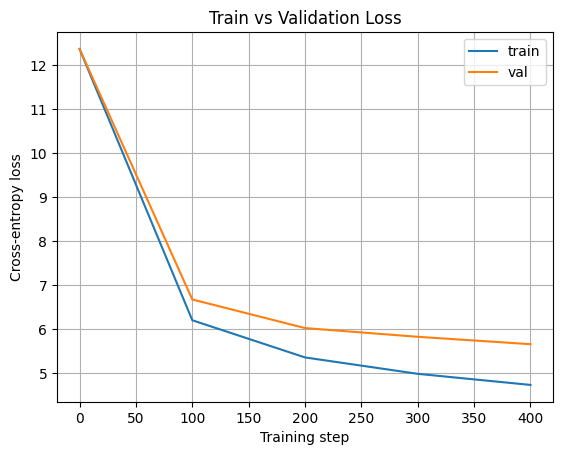

In [41]:
plt.plot(train_loss_history.keys(), train_loss_history.values(), label="train")
plt.plot(val_loss_history.keys(), val_loss_history.values(), label="val")

plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
model.eval()
with torch.no_grad():
    seed_token = token_ids[0]
    generated_indices = [seed_token]
    max_new_tokens = 100

    for _ in range(max_new_tokens):
        context = generated_indices[-block_size:]
        input_tensor = torch.tensor([context], dtype=torch.long, device=device)
        logits, _ = model(input_tensor)
        next_token = torch.argmax(logits[0, -1, :]).item()
        generated_indices.append(next_token)

    print("="*30, "\n", "Original Corpus", "\n", "="*30, "\n", corpus, "\n", "="*30, "\n")
    print("="*30, "\n", "Generated Corpus", "\n", "="*30, "\n", enc.decode(generated_indices), "\n", "="*30)

 Original Corpus 
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

A 

 Generated Corpus 
 First, I am a man of his
sces, and the king, and the king,
And I, my lord, and the king's
thee, and I have been to the king.

KING RICHARD III:
O, sir, I have done to the king.

KING RICHARD III:
O, sir, I have done to the king.

KING RICHARD III:
O, sir, I have done to the king.

KING RICHARD III:
O, 


In [43]:
def generate_text(model, prompt, max_new_tokens=20):
    model.eval()
    generated_indices = enc.encode(prompt)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = generated_indices[-block_size:]
            input_tensor = torch.tensor([context], dtype=torch.long, device=device)
            logits, _ = model(input_tensor)
            next_token_logits = logits[0, -1, :]
            next_token = torch.argmax(next_token_logits).item()
            generated_indices.append(next_token)
    return enc.decode(generated_indices)

In [44]:
prompt = "To be or not to be"
print(generate_text(model, prompt, max_new_tokens=20))

To be or not to be a king,
And, my lord, the king, and the king,
And I, my lord
